<a href="https://colab.research.google.com/github/Nikhilsankhyan0/Agrisheild-AI/blob/main/baseline_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np

from sklearn.preprocessing import (
    StandardScaler,
    LabelEncoder
)

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt

Mounted at /content/drive


In [3]:
x_train = pd.read_csv(
    "/content/drive/MyDrive/X_train_encoded.csv"
)

x_val = pd.read_csv(
    "/content/drive/MyDrive/X_val_encoded.csv"
)

x_test = pd.read_csv(
    "/content/drive/MyDrive/X_test_encoded.csv"
)

In [4]:
y_train_cls = pd.read_csv(
    "/content/drive/MyDrive/y_train_cls.csv"
).squeeze()

y_val_cls = pd.read_csv(
    "/content/drive/MyDrive/y_val_cls.csv"
).squeeze()

y_test_cls = pd.read_csv(
    "/content/drive/MyDrive/y_test_cls.csv"
).squeeze()

In [5]:
label_encoder = LabelEncoder()

y_train_cls_encoded = label_encoder.fit_transform(
    y_train_cls
)

y_val_cls_encoded = label_encoder.transform(
    y_val_cls
)

y_test_cls_encoded = label_encoder.transform(
    y_test_cls
)


In [8]:
label_encoder = LabelEncoder()

y_train_cls_encoded = label_encoder.fit_transform(
    y_train_cls
)

y_val_cls_encoded = label_encoder.transform(
    y_val_cls
)

y_test_cls_encoded = label_encoder.transform(
    y_test_cls
)

In [14]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_val_scaled = scaler.transform(x_val)
x_test_scaled = scaler.transform(x_test)



In [15]:
baseline_classifier = LogisticRegression(
    max_iter=800,
    random_state=42
)

baseline_classifier.fit(
    x_train_scaled,
    y_train_cls_encoded
)

LogisticRegression(max_iter=800, random_state=42)

In [16]:
y_pred_cls = baseline_classifier.predict(
    x_val_scaled
)

In [17]:
accuracy = accuracy_score(
    y_val_cls_encoded,
    y_pred_cls
)

print(
    f"Baseline Accuracy: {accuracy:.4f}"
)

Baseline Accuracy: 0.7710


In [18]:
print(
    classification_report(
        y_val_cls_encoded,
        y_pred_cls,
        target_names=label_encoder.classes_
    )
)

                          precision    recall  f1-score   support

                Approved       0.79      0.75      0.77       848
Approved with Conditions       0.71      0.76      0.74      1240
                Rejected       0.84      0.80      0.82       912

                accuracy                           0.77      3000
               macro avg       0.78      0.77      0.78      3000
            weighted avg       0.77      0.77      0.77      3000



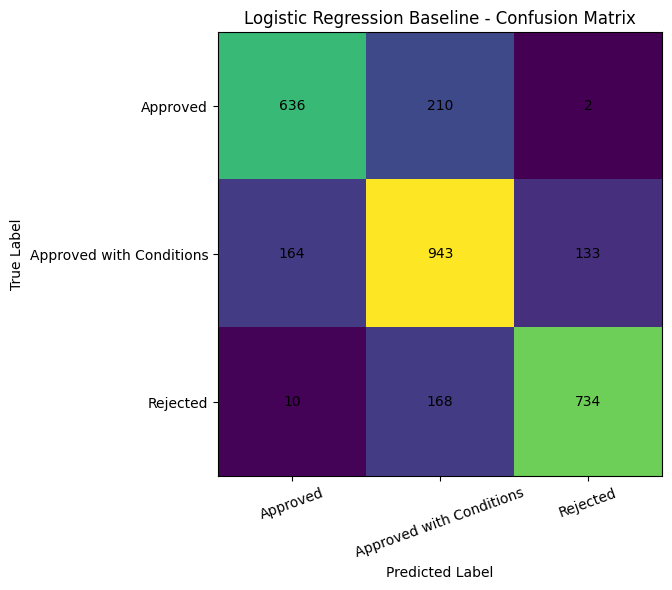

In [20]:
cm = confusion_matrix(
    y_val_cls_encoded,
    y_pred_cls
)

plt.figure(figsize=(7, 6))

plt.imshow(cm)

plt.xticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_,
    rotation=20
)

plt.yticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.title(
    "Logistic Regression Baseline - Confusion Matrix"
)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()